# 05 · GP kernel 与 EHVI 衰减（影响 P2 的设计，HANDOFF 未涉及）

这不是 HANDOFF 列出的任务，而是执行 §6 P2 时**必须先定下来**的两件事。


In [1]:
%matplotlib inline
import json, warnings
from pathlib import Path
from collections import Counter
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
plt.rcParams.update({
    "figure.dpi": 300, "savefig.dpi": 300, "font.size": 9,
    "axes.grid": True, "grid.alpha": .25,
    "axes.spines.top": False, "axes.spines.right": False,
})
R = Path("/lus/lfs1aip2/projects/public/u6gb/tasks/large-discovery-model/ldm_rl/results")
def load(name): return json.loads((R / name).read_text())

fp = load("gp_real_curve_fp.json")
sk = [(100, 573.77), (200, 3671.12)]     # two points from one run
a_sk = np.log(sk[1][1]/sk[0][1]) / np.log(sk[1][0]/sk[0][0])
fx = [d["n"] for d in fp if d["n"] >= 100]; fy = [d["seconds"] for d in fp if d["n"] >= 100]
a_fp = np.log(fy[-1]/fy[0]) / np.log(fx[-1]/fx[0])
print(f"sk exponent = {a_sk:.2f}   fp exponent = {a_fp:.2f}")

sk exponent = 2.68   fp exponent = 0.70


## 图 1 — sk 在生产规模上跑不完

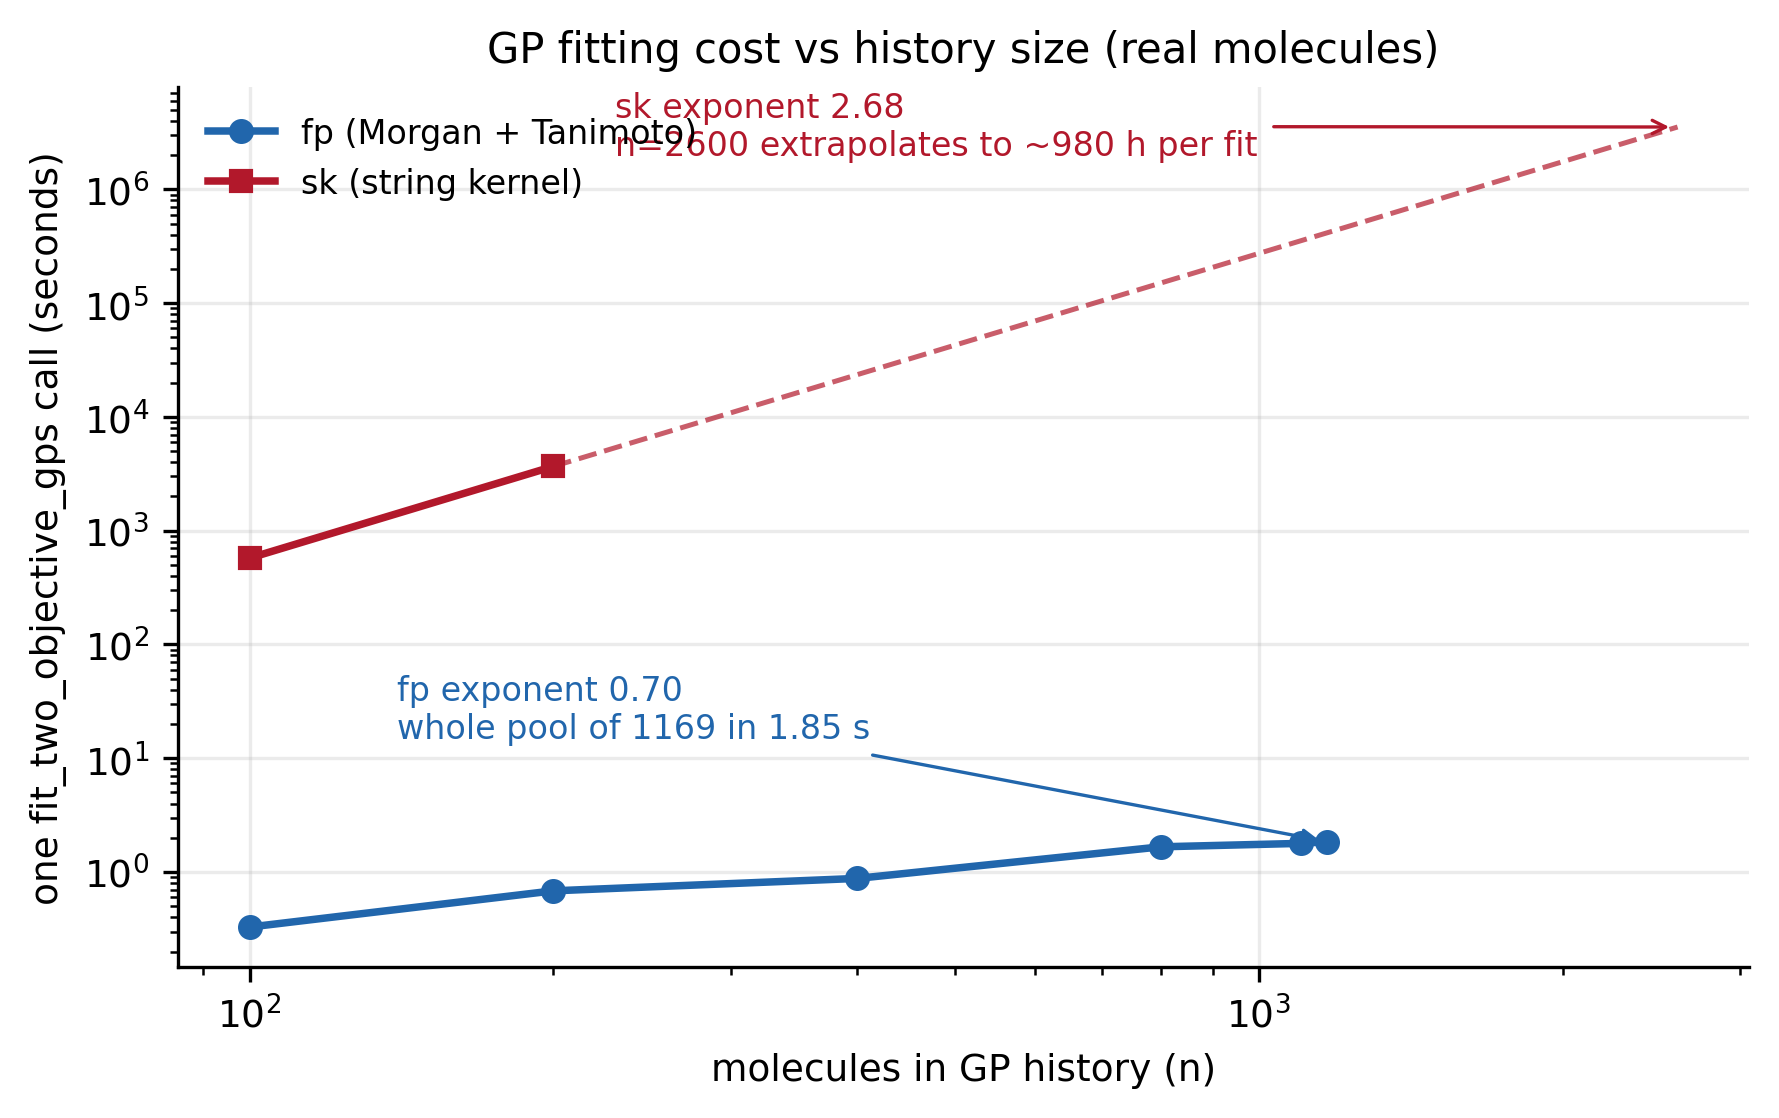

In [2]:
fig, ax = plt.subplots(figsize=(6.0, 3.8))
ax.loglog(fx, fy, "o-", color="#2166ac", lw=1.8, ms=5, label="fp (Morgan + Tanimoto)")
ax.loglog([p[0] for p in sk], [p[1] for p in sk], "s-", color="#b2182b", lw=1.8, ms=5,
          label="sk (string kernel)")
xe = np.array([200, 400, 800, 1500, 2600])
ax.loglog(xe, sk[1][1]*(xe/200)**a_sk, "--", color="#b2182b", lw=1.2, alpha=.7)
ax.annotate(f"sk exponent {a_sk:.2f}\nn=2600 extrapolates to "
            f"~{sk[1][1]*(2600/200)**a_sk/3600:.0f} h per fit",
            xy=(2600, sk[1][1]*(2600/200)**a_sk), xytext=(230, 2e6), fontsize=8,
            color="#b2182b", arrowprops=dict(arrowstyle="->", lw=.8, color="#b2182b"))
ax.annotate(f"fp exponent {a_fp:.2f}\nwhole pool of 1169 in {fy[-1]:.2f} s",
            xy=(1169, fy[-1]), xytext=(140, 15), fontsize=8, color="#2166ac",
            arrowprops=dict(arrowstyle="->", lw=.8, color="#2166ac"))
ax.set_xlabel("molecules in GP history (n)")
ax.set_ylabel("one fit_two_objective_gps call (seconds)")
ax.set_title("GP fitting cost vs history size (real molecules)", fontsize=10)
ax.legend(frameon=False, fontsize=8, loc="upper left")
plt.tight_layout(); plt.show()

**读法**：斜率就是阶。一个 run 要做约 **4000 次**这样的拟合、
池子会涨到 2600，所以 sk 不是「慢」，是**跑不完**。**P2 只能用 fp。**

代价是 fp 看不见 sk 能看见的一部分结构差异（top-5 重合 3/5，
Spearman 0.82），以及 Morgan 指纹会把不同 SMILES 映射到同一向量
（1169 个里撞 4 个，0.34%）。

## 图 2 — EHVI 随历史增长而衰减

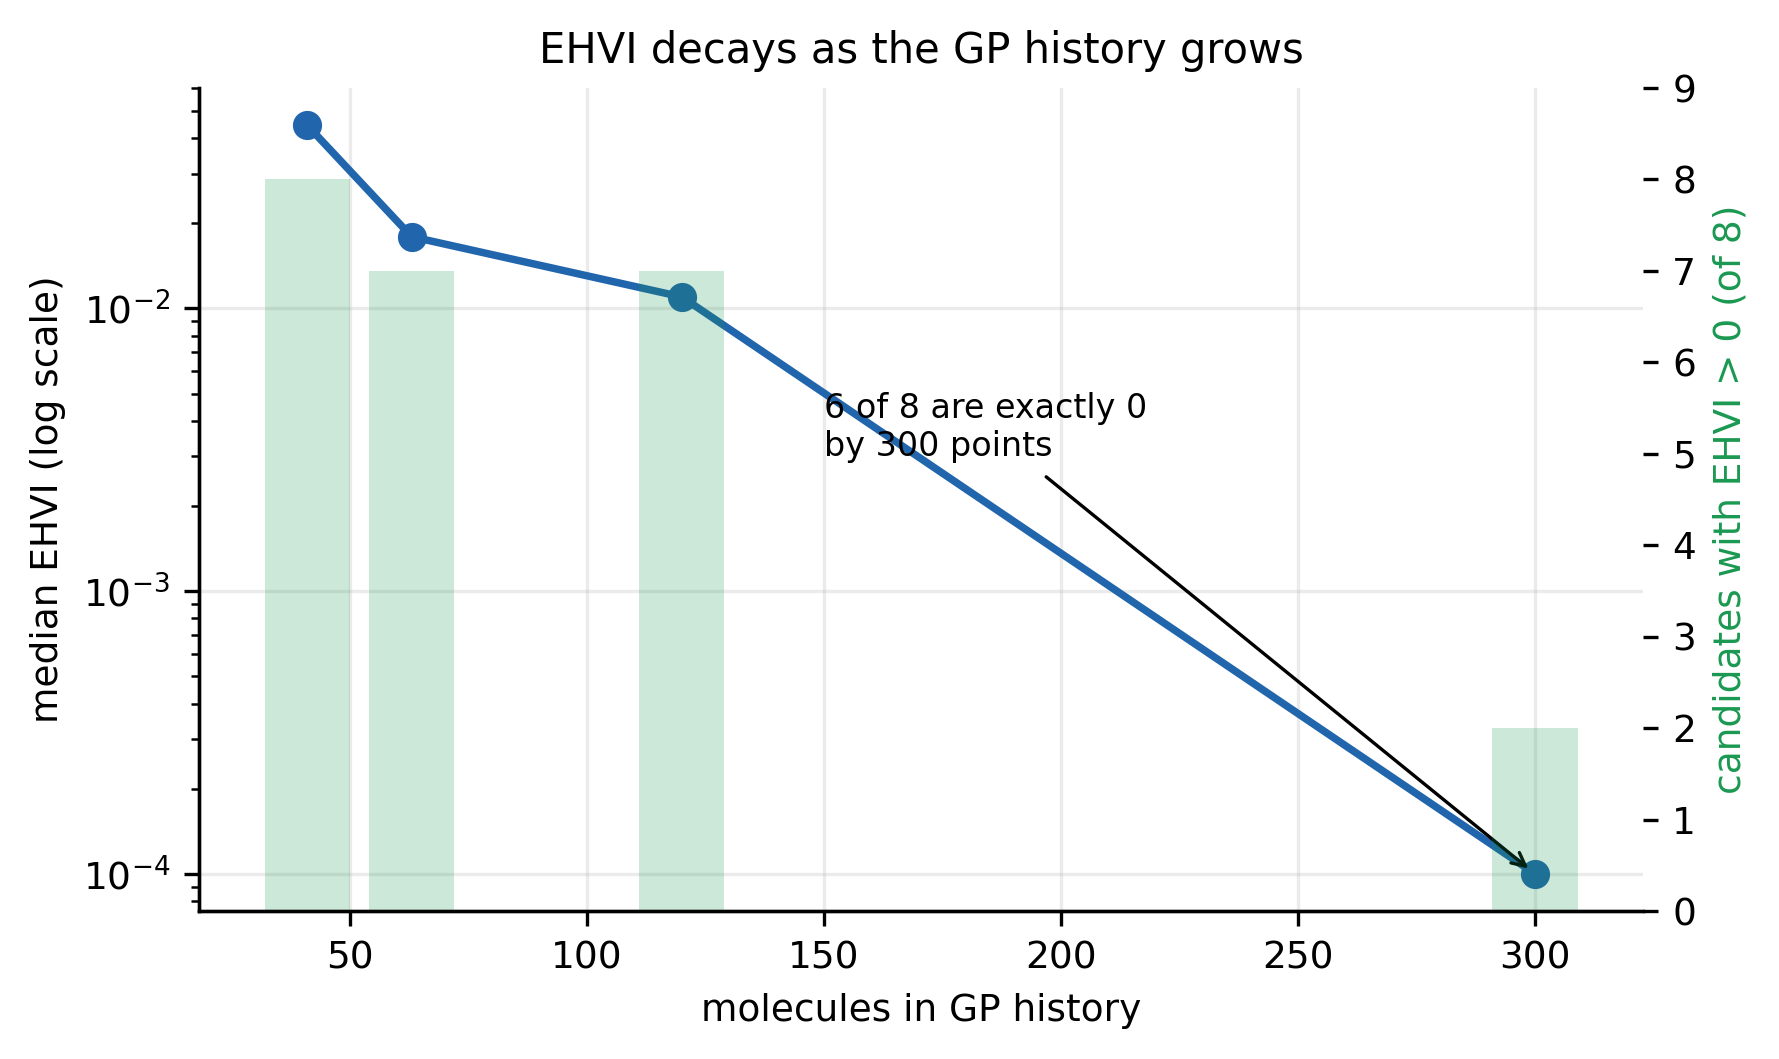

In [3]:
e = load("ehvi_vs_history.json")["points"]
n = [p["n_history"] for p in e]; med = [p["median"] for p in e]
zero = [p["n_zero"] for p in e]
fig, ax = plt.subplots(figsize=(6.0, 3.6))
ax.plot(n, [m if m > 0 else 1e-4 for m in med], "o-", color="#2166ac", lw=1.8, ms=6)
ax.set_yscale("log")
ax.set_xlabel("molecules in GP history"); ax.set_ylabel("median EHVI (log scale)")
ax2 = ax.twinx(); ax2.bar(n, [8-z for z in zero], width=18, alpha=.22, color="#1a9850")
ax2.set_ylabel("candidates with EHVI > 0 (of 8)", color="#1a9850")
ax2.set_ylim(0, 9); ax2.grid(False)
ax.annotate("6 of 8 are exactly 0\nby 300 points", xy=(300, 1e-4), xytext=(150, 3e-3),
            fontsize=8, arrowprops=dict(arrowstyle="->", lw=.8))
ax.set_title("EHVI decays as the GP history grows", fontsize=10)
plt.tight_layout(); plt.show()

**读法**：这是 EHVI 的**正常行为**——Pareto 前沿越好，新候选越难改进。
但一个 run 会积累到 500+ 个点，**一组候选一起拿到 0 的概率随之上升，
而那正是 [01](01_reward_always_zero.ipynb) 里零方差的另一个来源**。

可选的方向：定期重置参照点、换 acquisition、或对 reward 做长度归一化——
**这属于实验设计，应该由你和陈奕杭决定，不该由跑实验的人顺手改掉。**